# PLACES Health Data, Exploratory Data Analysis (Analyzer / Visualizer Notebook)

**Group 3:** Salam Odeh, Qossay Shtaiwi, Ali Odah

**Dataset:** PLACES: Local Data for Better Health, Census Tract Data (2024 release) — CDC / U.S. Department of Health & Human Services

**Role:** Analyzer / Visualizer

**Input:** `places_wide_clean.csv`, produced by the Data Wrangler notebook (`01_data_cleaning.ipynb`) — one row per census tract, one column per health measure, no missing values.

**Target variable:** `Diabetes` (% of adults with diagnosed diabetes, crude prevalence)

**Goal of this notebook:** understand the shape of the data, find which measures are most strongly related to diabetes prevalence, flag any data-interpretation issues the team should know about, and hand the Modeler a short, evidence-based list of features to prioritize.

**Tasks:**
1. Load the clean dataset and do a basic health check
2. Look at the distribution of the target variable (`Diabetes`)
3. Correlate every health measure against the target
4. Visualize the relationship between the target and the top predictors
5. Check for multicollinearity among the top predictors (important for the Modeler)
6. Look at the geographic (state-level) pattern
7. Summarize EDA findings for the Modeler and the final presentation


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')

## 2. Load the Clean Dataset

**Note on file path:** update `fpath` below to wherever `places_wide_clean.csv` was saved by the Data Wrangler notebook.

In [2]:
fpath = '../Data/places_wide_clean.csv'

df = pd.read_csv(fpath, dtype={'LocationName': str, 'CountyFIPS': str})
print(df.shape)
df.head()

(78784, 48)


,LocationName,StateAbbr,StateDesc,CountyName,CountyFIPS,TotalPopulation,TotalPop18plus,Geolocation,All Teeth Lost,Annual Checkup,Any Disability,Arthritis,Binge Drinking,COPD,Cancer (non-skin) or Melanoma,Cholesterol Screening,Cognitive Disability,Colorectal Cancer Screening,Coronary Heart Disease,Current Asthma,Current Cigarette Smoking,Dental Visit,Depression,Diabetes,Food Insecurity,Food Stamps,Frequent Mental Distress,Frequent Physical Distress,General Health,Health Insurance,Hearing Disability,High Blood Pressure,High Blood Pressure Medication,High Cholesterol,Housing Insecurity,Independent Living Disability,Lack of Social/Emotional Support,Loneliness,Mammography,Mobility Disability,Obesity,Physical Inactivity,Self-care Disability,Short Sleep Duration,Stroke,Transportation Barriers,Utility Services Threat,Vision Disability
0,01001020100,AL,Alabama,Autauga,01001,1775,1370,POINT (-86.4915648 32.4819731),13.4,80.1,35.7,30.6,14.8,8.2,8.5,85.5,16.8,65.0,7.2,10.2,15.6,57.3,26.6,13.3,17.0,11.6,17.9,14.7,22.5,9.7,8.6,41.4,77.8,41.9,12.3,9.6,23.5,33.0,78.0,16.3,39.4,27.8,4.4,37.9,3.8,8.9,8.1,5.5
1,01001020200,AL,Alabama,Autauga,01001,2055,1584,POINT (-86.4724678 32.475758),15.9,81.8,36.9,29.5,12.9,7.6,6.3,85.6,17.3,68.1,6.5,10.8,16.7,56.1,23.3,15.8,24.8,18.4,18.5,14.4,25.1,10.6,6.7,45.9,78.3,39.7,18.5,10.4,29.1,36.1,79.2,17.8,44.7,32.0,5.0,42.6,4.4,12.0,12.5,6.6
2,01001020300,AL,Alabama,Autauga,01001,3216,2485,POINT (-86.4597033 32.4740243),14.7,80.6,37.7,31.5,13.9,8.5,8.5,85.5,17.6,67.4,7.3,10.7,16.1,57.7,26.3,13.9,19.1,13.1,18.6,15.1,23.7,10.6,8.6,42.9,78.4,41.8,14.1,10.3,25.9,35.1,75.5,17.6,40.3,29.9,4.6,39.0,4.1,9.7,9.0,5.8
3,01001020400,AL,Alabama,Autauga,01001,4246,3344,POINT (-86.4448353 32.4710304),9.3,81.7,33.9,32.5,14.2,7.6,10.3,88.0,14.2,71.5,7.5,9.6,12.9,61.1,24.9,12.8,12.5,7.9,15.8,13.5,19.5,7.9,9.3,42.4,80.1,43.4,9.3,8.3,21.5,31.0,78.1,15.5,36.9,25.5,3.6,35.8,3.8,6.8,6.1,4.7
4,01001020501,AL,Alabama,Autauga,01001,4322,3369,POINT (-86.4225578 32.4478607),9.9,81.3,27.5,27.7,15.6,5.2,9.0,89.0,12.0,70.5,5.4,9.3,10.0,66.3,24.0,10.2,9.5,5.4,14.8,11.0,14.9,6.2,6.8,37.2,77.8,40.5,8.1,6.3,21.1,30.8,79.8,11.2,34.7,20.3,2.6,35.1,2.8,5.5,5.1,3.3


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 78784 entries, 0 to 78783
Data columns (total 48 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   LocationName                      78784 non-null  str    
 1   StateAbbr                         78784 non-null  str    
 2   StateDesc                         78784 non-null  str    
 3   CountyName                        78784 non-null  str    
 4   CountyFIPS                        78784 non-null  str    
 5   TotalPopulation                   78784 non-null  int64  
 6   TotalPop18plus                    78784 non-null  int64  
 7   Geolocation                       78784 non-null  str    
 8   All Teeth Lost                    78784 non-null  float64
 9   Annual Checkup                    78784 non-null  float64
 10  Any Disability                    78784 non-null  float64
 11  Arthritis                         78784 non-null  float64
 12  Binge Drinking 

In [4]:
# Confirm there's no missing data left over from the cleaning notebook
df.isna().sum().sum()

np.int64(0)

We're working with **78,784 census tracts** and **48 columns** (40 health measures + 8 reference columns like state, county, and population). Zero missing values, as expected from the cleaning step.

**Reference columns** (`LocationName`, `StateAbbr`, `StateDesc`, `CountyName`, `CountyFIPS`, `TotalPopulation`, `TotalPop18plus`, `Geolocation`) describe *where* a tract is, not a health measure — we'll set these aside when looking at correlations, but keep them for the geographic breakdown later.


In [5]:
ref_cols = ['LocationName', 'StateAbbr', 'StateDesc', 'CountyName', 'CountyFIPS',
            'TotalPopulation', 'TotalPop18plus', 'Geolocation']
measure_cols = [c for c in df.columns if c not in ref_cols]
print(f"Number of health measure columns: {len(measure_cols)}")

Number of health measure columns: 40


## 3. Distribution of the Target Variable (`Diabetes`)

Before looking at predictors, we need to understand what we're trying to predict.

In [6]:
df['Diabetes'].describe()

count    78784.000000
mean        12.436217
std          4.019813
min          0.700000
25%          9.800000
50%         11.900000
75%         14.500000
max         50.800000
Name: Diabetes, dtype: float64

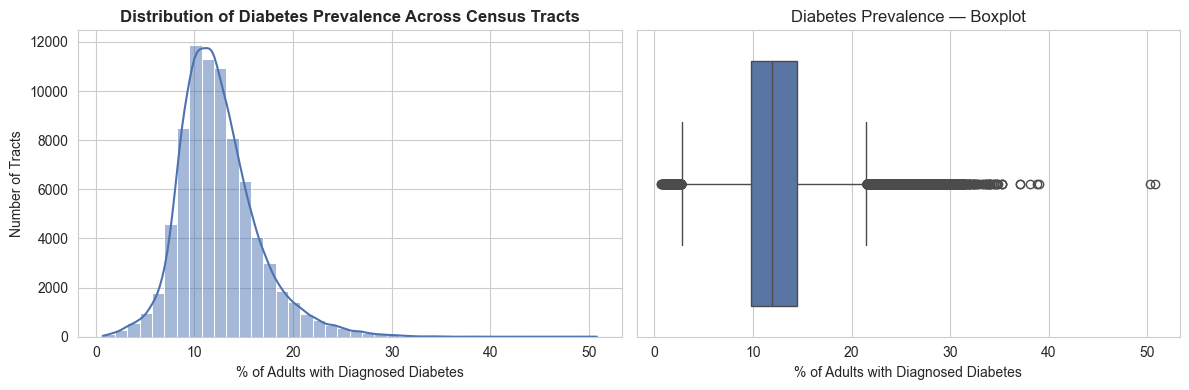

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['Diabetes'], bins=40, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribution of Diabetes Prevalence Across Census Tracts', fontweight='bold')
axes[0].set_xlabel('% of Adults with Diagnosed Diabetes')
axes[0].set_ylabel('Number of Tracts')

sns.boxplot(x=df['Diabetes'], ax=axes[1], color='#4C72B0')
axes[1].set_title('Diabetes Prevalence — Boxplot')
axes[1].set_xlabel('% of Adults with Diagnosed Diabetes')

fig.tight_layout()
plt.show()

The average census tract has about **12.4%** of adults with diagnosed diabetes, with most tracts falling somewhere between **9.8% and 14.5%** (the 25th–75th percentile range). The distribution has a **right-skewed tail** — a smaller number of tracts have much higher diabetes rates (up into the 30–50% range), rather than any tracts with unusually low rates. This tells us to expect a similar right-skew in several of the "risk" measures later on, and it's worth the Modeler trying both a plain regression and, if needed, a log-transformed target to see which fits better.


## 4. Correlation of Every Health Measure with Diabetes

We correlate every other measure against `Diabetes` to see which ones move together most strongly. This is the single most useful thing this notebook can hand to the Modeler.

In [8]:
predictor_cols = [c for c in measure_cols if c != 'Diabetes']

diabetes_corr = df[predictor_cols + ['Diabetes']].corr()['Diabetes'].drop('Diabetes').sort_values(ascending=False)
diabetes_corr

Mobility Disability                 0.953660
Stroke                              0.933823
Self-care Disability                0.903734
Frequent Physical Distress          0.868634
Physical Inactivity                 0.864146
High Blood Pressure                 0.861202
General Health                      0.856969
Vision Disability                   0.835978
Any Disability                      0.829457
COPD                                0.814407
Independent Living Disability       0.802204
Coronary Heart Disease              0.798982
Current Cigarette Smoking           0.761855
All Teeth Lost                      0.730195
Obesity                             0.713138
Utility Services Threat             0.628780
Short Sleep Duration                0.612418
Food Stamps                         0.612035
Food Insecurity                     0.610084
Cognitive Disability                0.604692
Hearing Disability                  0.597287
Arthritis                           0.584179
Transporta

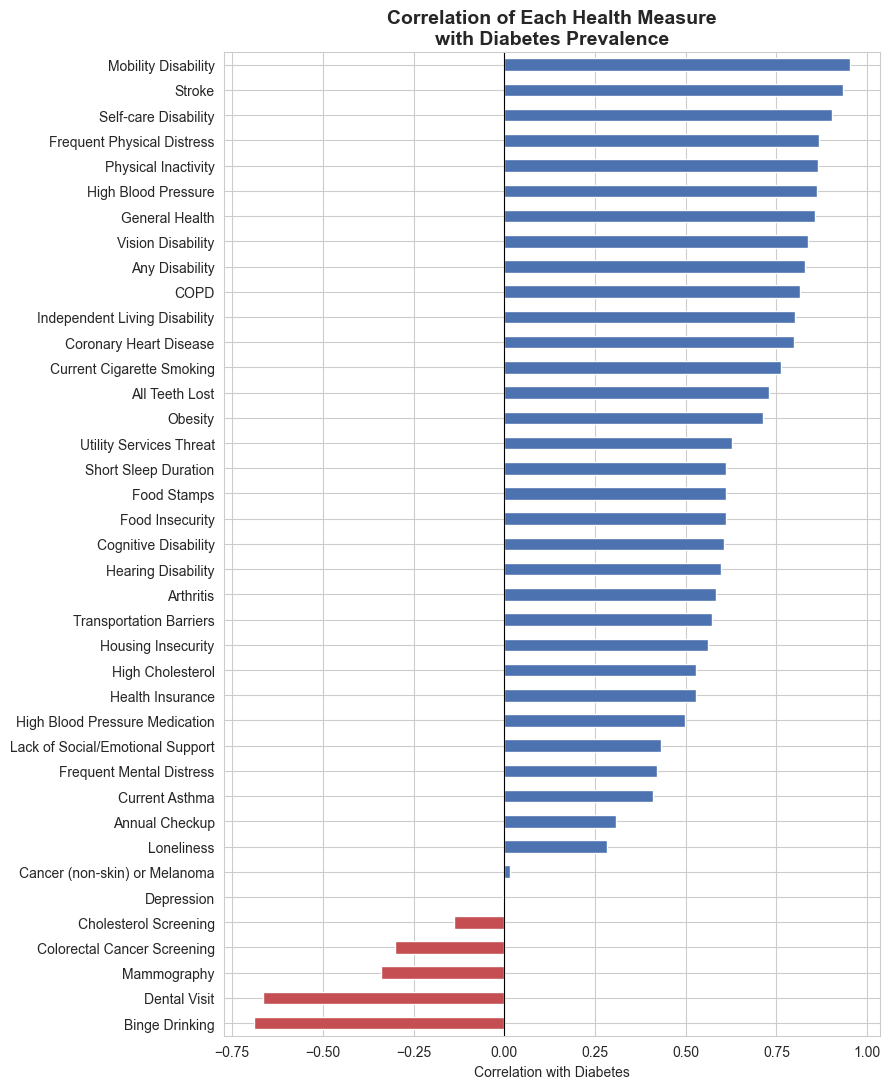

In [9]:
fig, ax = plt.subplots(figsize=(9, 11))
colors = ['#C44E52' if v < 0 else '#4C72B0' for v in diabetes_corr.values]
diabetes_corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation of Each Health Measure\nwith Diabetes Prevalence', fontweight='bold', fontsize=14)
ax.set_xlabel('Correlation with Diabetes')
ax.invert_yaxis()
fig.tight_layout()
plt.show()

**Key findings:**

- The strongest **positive** relationships are with **Mobility Disability** (r ≈ 0.95), **Stroke** (r ≈ 0.93), **Self-care Disability** (r ≈ 0.90), **Frequent Physical Distress** (r ≈ 0.87), and **Physical Inactivity** / **High Blood Pressure** (both r ≈ 0.86) — tracts where more adults struggle with mobility, have had a stroke, or are physically inactive also tend to have much higher diabetes rates. This lines up with what we'd expect medically: diabetes, cardiovascular disease, and mobility/disability outcomes tend to cluster together in the same populations.
- The strongest **negative** relationships are with **Binge Drinking** (r ≈ -0.69) and **Dental Visit** (r ≈ -0.67) — tracts with higher rates of *routine* dental care tend to have *lower* diabetes rates (likely a proxy for better healthcare access overall), and tracts with more binge drinking tend to have lower diabetes rates. **This second one is a good example of correlation, not causation** — it's more likely a marker of a younger population (binge drinking is more common among younger adults, who are also less likely to have diabetes yet) than binge drinking actually protecting against diabetes.
- ⚠️ **Important labeling catch:** the column named `Health Insurance` is actually **"Current lack of health insurance among adults aged 18-64"** — it measures the *lack* of insurance, not coverage. Its positive correlation (r ≈ 0.53) makes sense once you read it that way: more uninsured adults → higher diabetes prevalence, not the other way around. **We should rename this column something like `Uninsured_Rate` before modeling, or at minimum flag it clearly in the data dictionary**, so nobody on the team (or in the audience) misreads the direction during the presentation.


## 5. Visualize the Target vs. the Top Predictors

Numbers in a table are useful, but scatterplots make the relationships easier to communicate in the presentation.

In [10]:
top_features = diabetes_corr.abs().sort_values(ascending=False).head(6).index.tolist()
top_features

['Mobility Disability',
 'Stroke',
 'Self-care Disability',
 'Frequent Physical Distress',
 'Physical Inactivity',
 'High Blood Pressure']

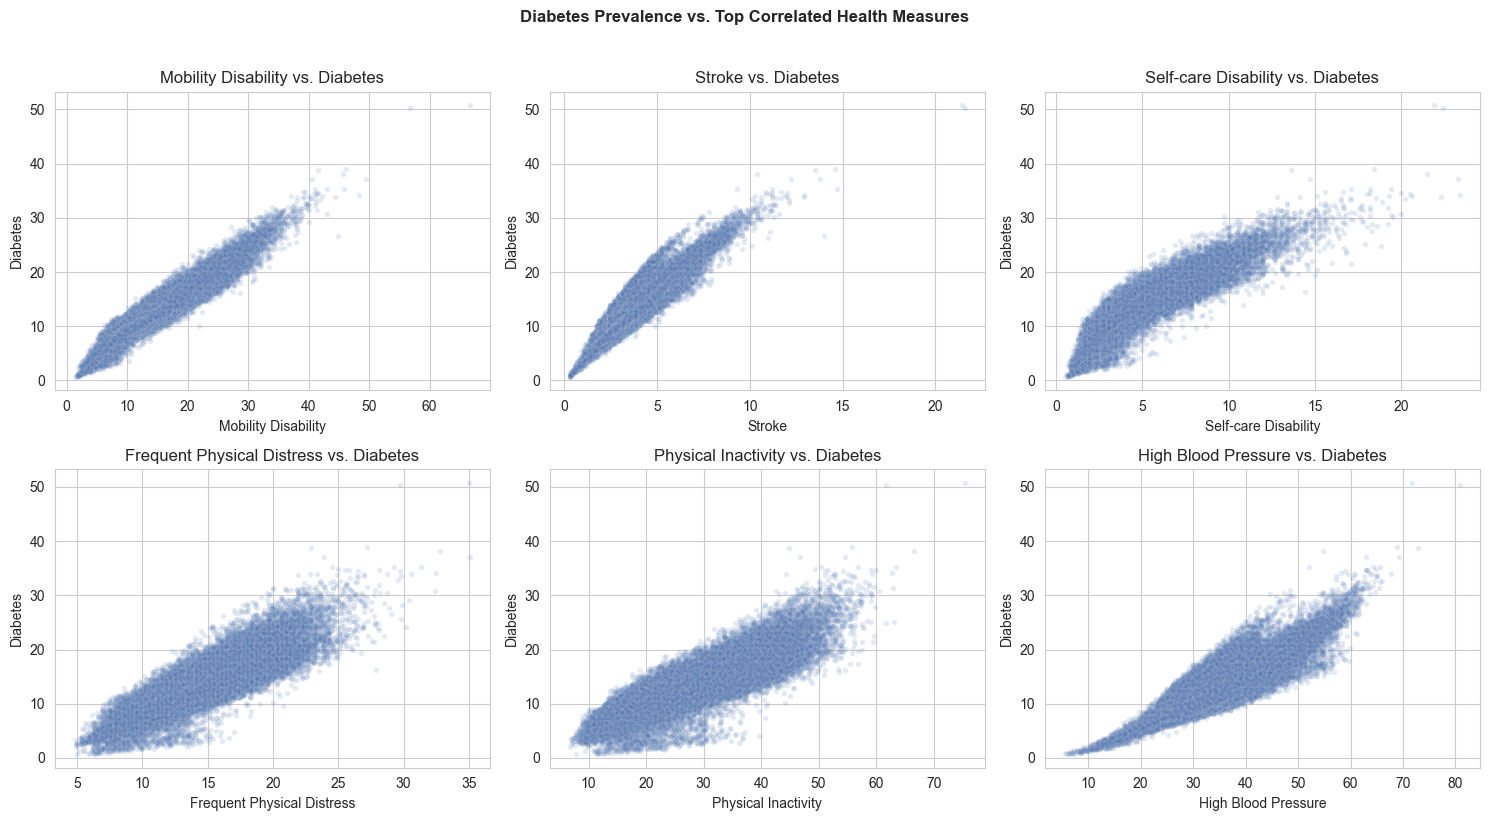

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    sns.scatterplot(data=df, x=feat, y='Diabetes', alpha=0.15, s=15, ax=axes[i], color='#4C72B0')
    axes[i].set_title(f'{feat} vs. Diabetes')

fig.suptitle('Diabetes Prevalence vs. Top Correlated Health Measures', fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

Each of these shows a clear, roughly linear upward (or downward) trend, with the expected amount of scatter around it — reassuring, since it means a regression-style model should be able to pick up on these relationships rather than needing a highly complex, non-linear approach.

## 6. Check for Multicollinearity Among Top Predictors

Several of our strongest predictors are plausibly measuring overlapping things (e.g. mobility disability, stroke, and physical inactivity are all connected to the same underlying population health profile). If we hand a linear model a set of highly correlated features, its individual coefficients become unstable and hard to interpret — worth flagging for the Modeler now.

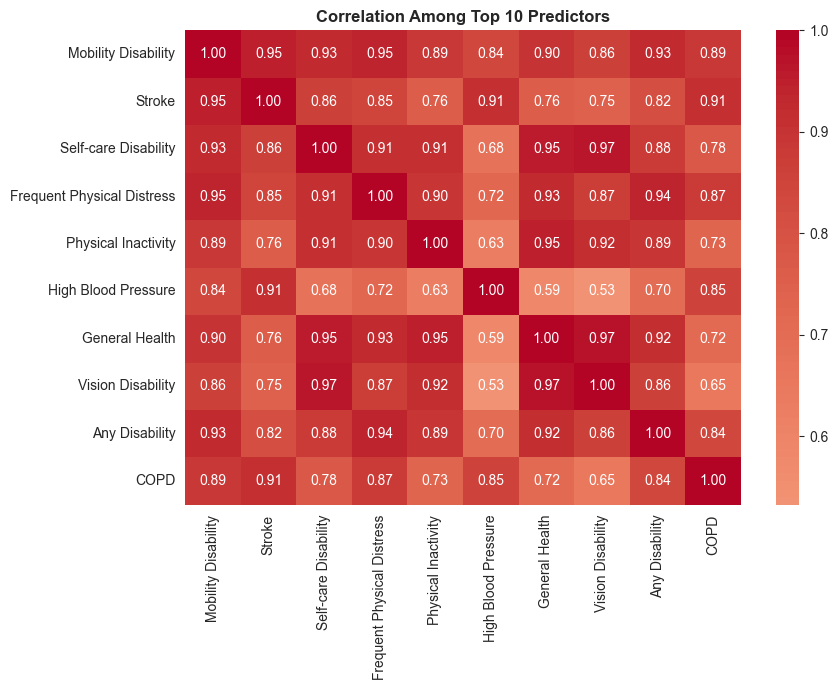

In [12]:
top_10_features = diabetes_corr.abs().sort_values(ascending=False).head(10).index.tolist()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[top_10_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Among Top 10 Predictors', fontweight='bold')
fig.tight_layout()
plt.show()

**Finding:** several pairs among the top predictors are very highly correlated with each other — for example, `Mobility Disability` and `Stroke` (r ≈ 0.95), and `Self-care Disability` and `Vision Disability` (r ≈ 0.97). This is a real **multicollinearity** concern.

**Recommendation for the Modeler:**
- Tree-based models (Random Forest, Gradient Boosting) handle correlated features gracefully and are a safer first choice for this dataset.
- If a Linear Regression baseline is used for comparison, its individual coefficients should be interpreted cautiously (or the Modeler could try dropping some of the redundant features, or using Ridge regression, which handles multicollinearity better than plain Linear Regression).


## 7. Geographic Pattern: Average Diabetes Prevalence by State

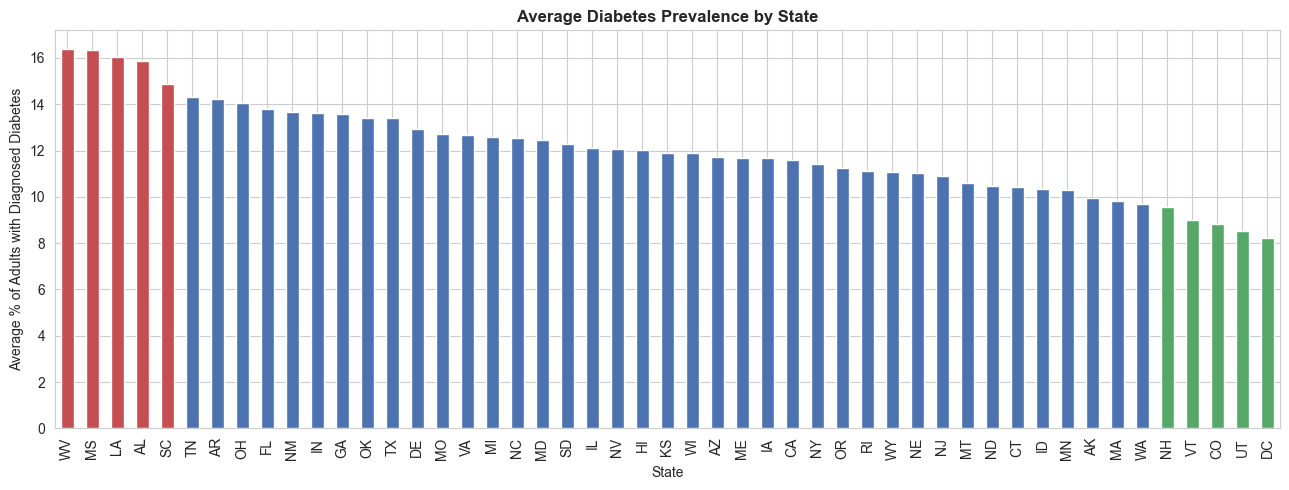

In [13]:
state_avg = df.groupby('StateAbbr')['Diabetes'].mean().sort_values(ascending=False)

# Highlight the top 5 (red) and bottom 5 (green) states so they stand out
colors = ['#C44E52' if i < 5 else ('#55A868' if i >= len(state_avg) - 5 else '#4C72B0')
          for i in range(len(state_avg))]

fig, ax = plt.subplots(figsize=(13, 5))
state_avg.plot(kind='bar', ax=ax, color=colors)
ax.set_title('Average Diabetes Prevalence by State', fontweight='bold')
ax.set_ylabel('Average % of Adults with Diagnosed Diabetes')
ax.set_xlabel('State')
fig.tight_layout()
plt.show()

In [14]:
print("Top 5 states by average diabetes prevalence:")
print(state_avg.head())
print()
print("Bottom 5 states by average diabetes prevalence:")
print(state_avg.tail())

Top 5 states by average diabetes prevalence:
StateAbbr
WV    16.368132
MS    16.358343
LA    16.033285
AL    15.845944
SC    14.865473
Name: Diabetes, dtype: float64

Bottom 5 states by average diabetes prevalence:
StateAbbr
NH    9.541499
VT    9.019271
CO    8.840779
UT    8.523803
DC    8.223301
Name: Diabetes, dtype: float64


There's a clear regional pattern: **West Virginia, Mississippi, Louisiana, Alabama, and South Carolina** have the highest average tract-level diabetes prevalence (all around 14.9–16.4%), while **New Hampshire, Vermont, Colorado, Utah, and DC** have the lowest (around 8.2–9.5%). This is broadly consistent with well-documented regional health disparities in the U.S. ("Diabetes Belt" states in the Southeast) and is a nice, easy-to-explain visual for the presentation — but it's a *description* of the pattern, not something we'd feed into the model as a feature, since state is more of a proxy for many of the other measures we already have (poverty, access to care, obesity, etc.) rather than a cause on its own.

**Also worth noting for the presentation:** this export now covers **49 of the 50 states + DC** — only Kentucky and Pennsylvania are absent (see the Data Wrangler notebook) — so this chart is close to a full national picture, not the more limited state coverage of earlier drafts of this dataset.


## 8. Summary of EDA Findings (for the Modeler and Presentation)

1. **Target distribution:** `Diabetes` prevalence averages **~12.4%** per tract, ranges roughly **0.7%–50.8%**, and is **right-skewed** — most tracts cluster between 9.8–14.5%, with a smaller number of high-prevalence outlier tracts pulling the tail up.

2. **Strongest predictors (positive):** `Mobility Disability`, `Stroke`, `Self-care Disability`, `Frequent Physical Distress`, `Physical Inactivity`, and `High Blood Pressure` — all correlate with Diabetes at **r > 0.8** (and several others — `General Health`, `Vision Disability`, `Any Disability`, `COPD` — now also clear r > 0.8). These should be the Modeler's starting feature set.

3. **Strongest predictors (negative):** `Binge Drinking` (r ≈ **-0.69**) and `Dental Visit` (r ≈ **-0.67**) — likely proxies for population age and healthcare access rather than direct causes, worth explaining carefully rather than taking at face value.

4. **Data labeling issue to fix before modeling:** the `Health Insurance` column actually measures the **lack** of insurance. Recommend renaming it (e.g. `Uninsured_Rate`) so the direction of its coefficient/importance isn't misread by the team or the audience.

5. **Multicollinearity:** several top predictors are highly correlated *with each other* (e.g. Mobility Disability & Stroke, r ≈ 0.95). This favors tree-based models for the main result, with a linear model kept only as an interpretability baseline (and interpreted cautiously).

6. **Geographic pattern:** clear regional clustering (Southeastern states highest, Mountain/Northeast states lowest), consistent with known U.S. health disparity patterns — good narrative context for the presentation, but not a recommended standalone model feature.

7. **Scope limitation:** this export now covers 49 of 50 states + DC (only Kentucky and Pennsylvania are missing) — close to a full national picture, but still worth stating explicitly during the presentation.
